In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("christchurch_listings_2025-10_to_2026-06.csv")

print("Shape of the final dataset:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

Shape of the final dataset: (28795, 19)

Columns: ['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'license', 'month_year']

First 5 rows:
             id                            name      host_id  \
0  4.018376e+07        Ensuite Cabin (Sleeps 6)   98758734.0   
1  1.149729e+18  Handy city center. Simple room  298456605.0   
2  1.097487e+06      Heritage Magic in Merivale    4993285.0   
3  1.339648e+18         Settle into the sun set   54299306.0   
4  1.211070e+18             Eco Spa-bath Studio  179297759.0   

                  host_name neighbourhood_group   neighbourhood   latitude  \
0  North South Holiday Park   Christchurch City   Harewood Ward -43.470020   
1                      Tony   Christchurch City    Central Ward -43.532700   
2          

In [4]:
print("\n=== STASTICAL VALUES ===")
print(df.describe(include='all').round(2))
print("\n=== CATEGORICAL COLUMNS ===")
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())



=== STASTICAL VALUES ===
                  id                  name       host_id            host_name  \
count   2.879500e+04                 28795  2.879500e+04                28794   
unique           NaN                  4854           NaN                 1422   
top              NaN  Room in Christchurch           NaN  Paula Kat Charlotte   
freq             NaN                    23           NaN                 1561   
mean    9.030627e+17                   NaN  1.988281e+15                  NaN   
std     5.945297e+17                   NaN  5.782999e+16                  NaN   
min     2.040500e+05                   NaN  5.738200e+04                  NaN   
25%     5.237109e+07                   NaN  6.395537e+07                  NaN   
50%     1.089973e+18                   NaN  1.721473e+08                  NaN   
75%     1.393916e+18                   NaN  4.471452e+08                  NaN   
max     1.709886e+18                   NaN  1.704737e+18                  NaN   

 

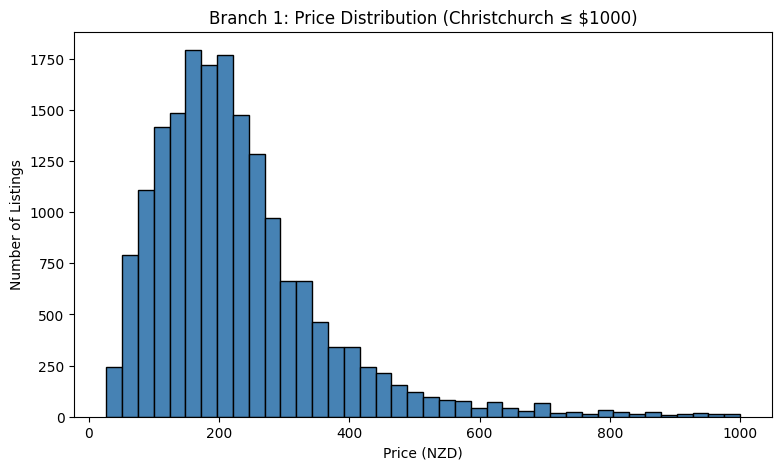

In [5]:
df_price = df[df['price'] <= 1000].copy()

plt.figure(figsize=(9, 5))
plt.hist(df_price['price'].dropna(), bins=40, edgecolor='black', color='steelblue')
plt.title("Branch 1: Price Distribution (Christchurch ≤ $1000)")
plt.xlabel("Price (NZD)")
plt.ylabel("Number of Listings")
plt.show()

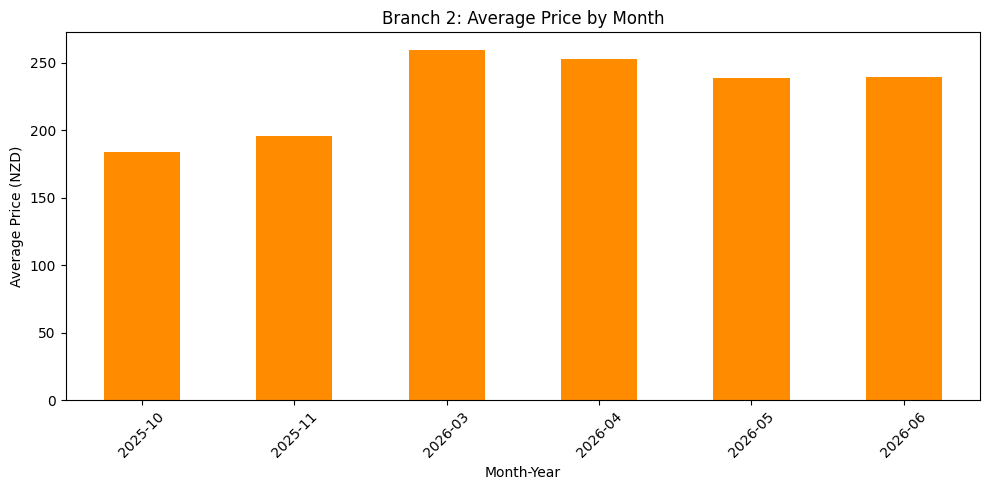

In [6]:
# BRANCH 2: Price by month (example)
plt.figure(figsize=(10, 5))
df_price.groupby('month_year')['price'].mean().plot(kind='bar', color='darkorange')
plt.title("Branch 2: Average Price by Month")
plt.xlabel("Month-Year")
plt.ylabel("Average Price (NZD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




In [7]:
# 1. Convert last_review to datetime (keep this)
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

# 2. Mapping of month_year → real scrape date from Inside Airbnb
# Why this mapping?
# Each monthly file was collected on a specific day.
# “Days since last review” only makes sense when measured against the actual day the data was scraped.
scrape_dates = {
    '2025-10': '2025-10-05',
    '2025-11': '2025-11-07',
    '2025-12': '2025-12-11',
    '2026-01': '2026-01-16',
    '2026-02': '2026-02-13',
    '2026-03': '2026-03-17',
    '2026-04': '2026-04-16',
    '2026-05': '2026-05-23',
    '2026-06': '2026-06-19'
}

# 3. Create the correct reference date for every row
df['ref_date'] = pd.to_datetime(df['month_year'].map(scrape_dates))

# 4. Calculate days since last review using the correct date for that month
df['days_since_last_review'] = (df['ref_date'] - df['last_review']).dt.days



/tmp/ipykernel_1248/3111367473.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')


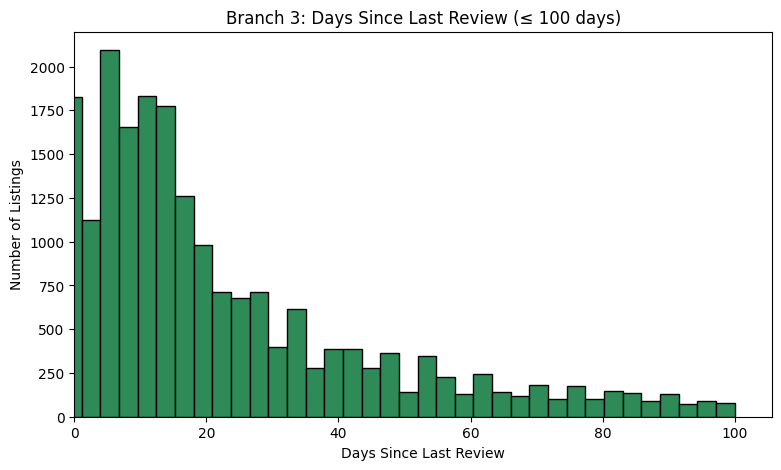

In [8]:
df_recent = df[df['days_since_last_review'] <= 100].copy()

plt.figure(figsize=(9, 5))
plt.hist(df_recent['days_since_last_review'].dropna(), bins=40, edgecolor='black', color='seagreen')
plt.title("Branch 3: Days Since Last Review (≤ 100 days)")
plt.xlabel("Days Since Last Review")
plt.ylabel("Number of Listings")
plt.xlim(left=0)
plt.show()

In [9]:
# BRANCH 4: Rank by number of reviews → Top 10%
df['Rank'] = df['number_of_reviews'].rank(ascending=False, method='first')
top_10_percent = int(len(df) * 0.10)

df_top10 = df[df['Rank'] <= top_10_percent].copy()

print("Total listings in the dataset:", len(df))
print("Top 10% cutoff (Rank ≤ ):", top_10_percent)
print("Number of listings in Top 10%:", len(df_top10))

print("\n=== Top 10% most reviewed listings ===")
print(df_top10[['Rank', 'name', 'neighbourhood_group', 'month_year', 'price', 'number_of_reviews']]
      .sort_values('Rank')
      .head(20))

Total listings in the dataset: 28795
Top 10% cutoff (Rank ≤ ): 2879
Number of listings in Top 10%: 2879

=== Top 10% most reviewed listings ===
       Rank                                           name  \
26541   1.0                              lazy porch studio   
23613   2.0                              lazy porch studio   
18739   3.0                              lazy porch studio   
27390   4.0    Airport Studio, King bed. NO CLEANING  FEE.   
22574   5.0    Airport Studio, King bed. NO CLEANING  FEE.   
15511   6.0                              lazy porch studio   
18793   7.0    Airport Studio, King bed. NO CLEANING  FEE.   
13413   8.0                              lazy porch studio   
15566   9.0    Airport Studio, King bed. NO CLEANING  FEE.   
10727  10.0                              lazy porch studio   
7337   11.0                              lazy porch studio   
13562  12.0    Airport Studio, King bed. NO CLEANING  FEE.   
5831   13.0                              lazy porc